# Regularization

### Ridge Regularization L2 Penalty

* It's a linear regression with **penalty**. It can be demonstated that there is no equation for finding the best $\lambda$ coefficent of the weights
* The weights of many parameters goes to zero to take care of overfitting by **reducing big oscillations** that would lead to high variance performances. It's called **shrinkage selection**.
* Bayes equivalent of this regularization is **Gaussian priors**

### Lasso Regularization L1 Penalty

* Penalties results in parameters selection. Some weights are put to zero in a completly data driven way. No need to choose a priori.
* Differntly from Ridge the Lasso regularization is a L1 norm, giving a different weight.
* Bayes equivalent of this regularization is **Laplace priors**

## Comparing Regularization 

### Regolarizzazione: Ridge vs Lasso

**Differenze Chiave:**
*   **Ridge ($L_2$):** Applica uno *shrinkage* continuo. Riduce la grandezza di tutti i pesi senza mai portarli esattamente a zero. È ideale quando ci si aspetta che tutte le feature del dataset abbiano una qualche utilità fisica. Gestisce bene le variabili correlate distribuendo il peso tra di esse. Geometricamente, impone un vincolo sferico.
*   **Lasso ($L_1$):** Esegue una **Feature Selection** intrinseca. È in grado di forzare i pesi delle feature meno rilevanti *esattamente a zero*, producendo un modello "rado" (sparse). Se incontra variabili altamente correlate, tende a sceglierne una a caso azzerando le altre. Geometricamente, impone un vincolo a forma di rombo (o iper-ottaedro) le cui "punte" favoriscono l'azzeramento sugli assi.

### Funzioni di Costo (Loss Functions)

**1. Ridge Regression ($L_2$ Penalty):**
Penalizza la somma dei quadrati dei pesi.
$$ \text{Loss}_{\text{Ridge}} = \frac{1}{2N} \sum_{i=1}^{N} (y_i - w^T x_i)^2 + \lambda \sum_{j=1}^{M} w_j^2 $$

**2. Lasso Regression ($L_1$ Penalty):**
Penalizza la somma dei valori assoluti dei pesi.
$$ \text{Loss}_{\text{Lasso}} = \frac{1}{2N} \sum_{i=1}^{N} (y_i - w^T x_i)^2 + \lambda \sum_{j=1}^{M} |w_j| $$

*(Dove $N$ è il numero di campioni, $M$ il numero di feature, e $\lambda$ è l'iperparametro che controlla la forza della regolarizzazione).*

### Generalizzazione della Penalità

Sia Ridge che Lasso sono casi specifici di una penalizzazione basata sulla norma $L_p$ generalizzata. Il termine di regolarizzazione generale può essere scritto come:

$$ \text{Penalità} = \lambda \sum_{j=1}^{M} |w_j|^p $$
* Se **$p = 1$**, otteniamo il Lasso.
* Se **$p = 2$**, otteniamo la Ridge.
* Se $0 < p < 1$, si ottiene una selezione di feature ancora più aggressiva (ma il problema matematico diventa non-convesso).

**Nota pratica (Elastic Net):**
Nel machine learning moderno, per unire i vantaggi di entrambi (la *feature selection* del Lasso e la stabilità del Ridge sulle variabili correlate), si usa spesso la generalizzazione **Elastic Net**, che è semplicemente una combinazione lineare delle due penalità:
$$ \text{Loss}_{\text{ElasticNet}} = \text{MSE} + \lambda_1 \sum_{j=1}^{M} |w_j| + \lambda_2 \sum_{j=1}^{M} w_j^2 $$

### How to choose $\lambda$?

We use cross-validation, just as we discussed last time. In fact...Scikit-Learn has versions of Ridge and LASSO regression that do this automatically for you: see RidgeCV and LassoCV.

# Supernovae Distances and Redshifts

### Data Visualization

In [1]:
from astropy.cosmology import LambdaCDM
from astroML.datasets import generate_mu_z
import astroML.linear_model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

/opt/anaconda3/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

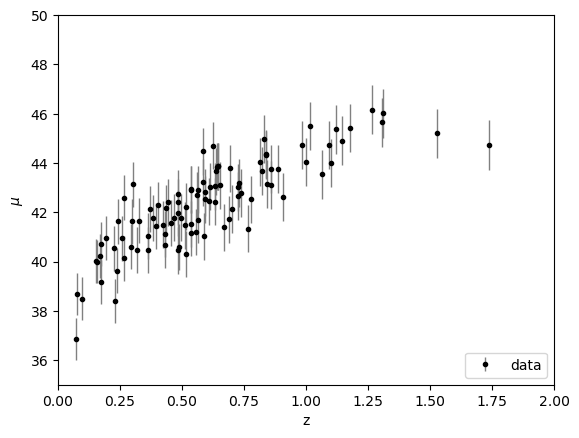

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(rf"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Gaussian Process Regression

(35.0, 50.0)

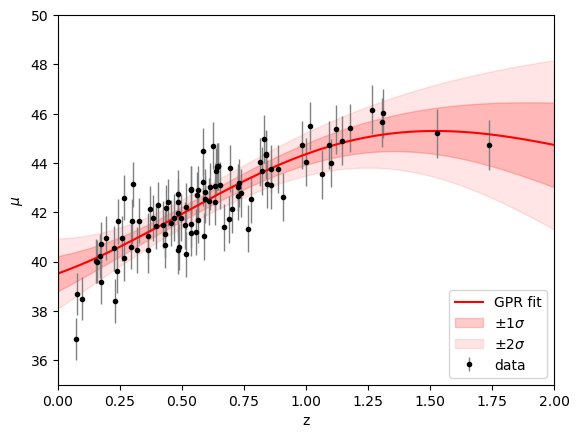

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
import numpy as np

#The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
#Gaussian process can be completely specified by its mean and covariance function.

kernel = kernels.RBF() * kernels.ConstantKernel()   
gpr = GaussianProcessRegressor(kernel=kernel, alpha=dmu*2, normalize_y=True)
#alpha riflette il rumore sui dati, eteroschedastico gaussiano

gpr.fit(z_sample[:, None], mu_sample)
z_fit = np.linspace(0, 2, 1000)
mu_fit, dmu_fit = gpr.predict(z_fit[:, None], return_std=True) # type: ignore

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_fit, mu_fit, '-r', label='GPR fit')
plt.fill_between(z_fit, mu_fit - dmu_fit, mu_fit + dmu_fit, color='r', alpha=0.2, label=rf'$\pm 1\sigma$')
plt.fill_between(z_fit, mu_fit - 2*dmu_fit, mu_fit + 2*dmu_fit, color='r', alpha=0.1, label=rf'$\pm 2\sigma$')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


* Don't trust the internal optimizer, we should really validate through cross validating the bandwidth. 
* Where there are fewer points the bandwitdh naturally tend to be bigger without explore too much like polinomials
* Given the model to do cloning we need to know density in indipendent component and then we can evaluate the predicted model on such density points

### Cloning Data

In [4]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

#kde on redshift, log
bandwidths = 10 ** np.linspace(-2, 0, 50)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),{'bandwidth': bandwidths},cv=5)
grid.fit(z_sample[:, None])

kde = grid.best_estimator_
print(rf"Bandwidth ottimale trovata per la KDE: {kde.bandwidth:.4f}")

n_clones = 1500
#Campioniamo i nuovi redshift dalla KDE
z_clone = kde.sample(n_clones, random_state=42)
z_clone = z_clone[z_clone[:, 0] > 0]

#curva best fit con errore locale
mu_pred, dmu_pred = gpr.predict(z_clone, return_std=True)
mu_clone = np.random.normal(mu_pred, dmu_pred)

Bandwidth ottimale trovata per la KDE: 0.1389


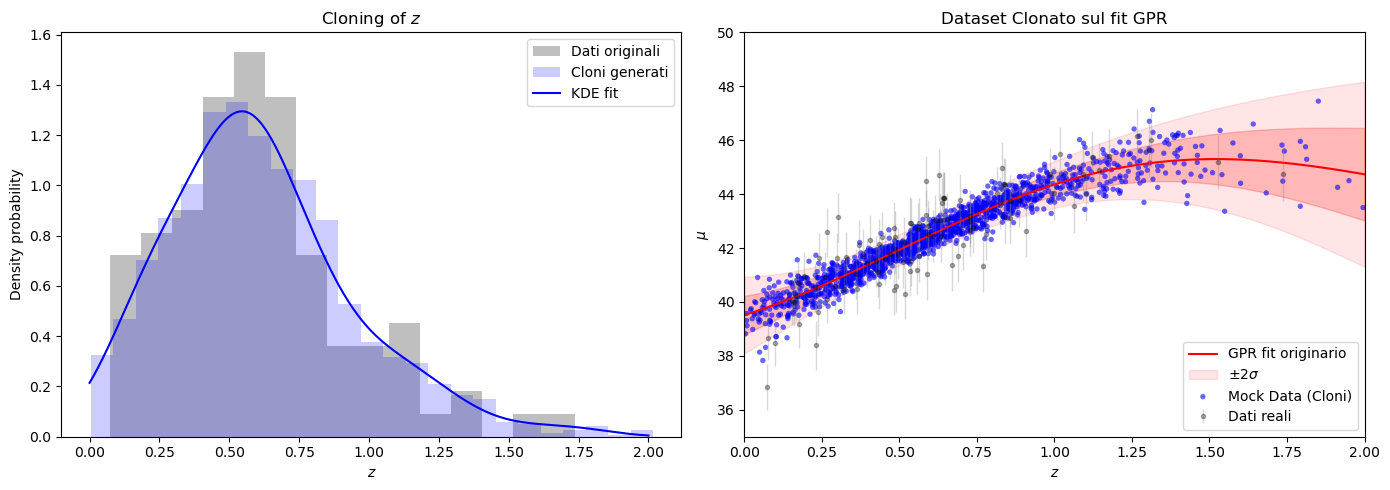

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(z_sample, bins=15, density=True, color='gray', alpha=0.5, label='Dati originali')

z_grid = np.linspace(0, 2, 500)
kde_pdf = np.exp(kde.score_samples(z_grid[:, None]))
ax[0].hist(z_clone, bins=25, density=True, color='blue', alpha=0.2, label='Cloni generati')
ax[0].plot(z_grid, kde_pdf, '-b', label='KDE fit')
ax[0].set_xlabel('$z$')
ax[0].set_ylabel('Density probability')
ax[0].legend()
ax[0].set_title('Cloning of $z$')


ax[1].plot(z_fit, mu_fit, '-r', label='GPR fit originario')
ax[1].fill_between(z_fit, mu_fit - dmu_fit, mu_fit + dmu_fit, color='r', alpha=0.2)
ax[1].fill_between(z_fit, mu_fit - 2*dmu_fit, mu_fit + 2*dmu_fit, color='r', alpha=0.1, label=rf'$\pm 2\sigma$')
ax[1].errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, alpha=0.3, label='Dati reali')
ax[1].scatter(z_clone, mu_clone, s=15, color='blue', alpha=0.6, edgecolors='none', label='Mock Data (Cloni)')
ax[1].set_xlabel('$z$')
ax[1].set_ylabel(rf'$\mu$')
ax[1].legend(loc='lower right')
ax[1].set_xlim(0, 2)
ax[1].set_ylim(35, 50)
ax[1].set_title('Dataset Clonato sul fit GPR')

plt.tight_layout()
plt.show()

### Lambda CDM Model

In [6]:
import emcee
import scipy
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyutils
import corner

In [7]:
# Define the model
def LambdaCDM(z, H0, omegaM):
    c = 299792.458
    omegaL = 1 - omegaM

    def integrand(x):
        return 1.0 / np.sqrt(omegaM * (1 + x)**3 + omegaL)

    z_arr = np.atleast_1d(z)
    integral = np.array([scipy.integrate.quad(integrand, 0, zi)[0] for zi in z_arr])
    d_l_mpc = (100000 * c / H0) * (1 + z_arr) * integral
    mu = 5 * np.log10(d_l_mpc)

    return mu.item() if np.isscalar(z) else mu

# Define the logLikelihood
def logLikelihood(theta, z, mu, error):
    H0, omegaM = theta
    model = LambdaCDM(z, H0, omegaM)
    logL = -0.5 * np.sum(((mu - model) / error) ** 2)
    return logL

# Define the logPrior
def logPrior(theta):
    H0, omegaM = theta
    if 0 < H0 < 100 and 0 < omegaM < 1:
        return 0.0  
    return -np.inf  

# Define the prior transformation
def priorTransform(u):
    H0 = 100 * u[0]  # Map u[0] from [0, 1] to [0, 100]
    omegaM = u[1]  # Map u[1] from [0, 1] to [0, 1]
    return H0, omegaM

# Define logPosterior
def logPosterior(theta, z, mu, error):
    lp = logPrior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, z, mu, error)

In [8]:
ndim = 2 #H0 e Omega
sampler = dynesty.NestedSampler(
    loglikelihood= lambda theta: logLikelihood(theta, z_sample, mu_sample, dmu),
    prior_transform=priorTransform,
    ndim=ndim,
    nlive=500,
    sample='auto'
)

print("Avvio del Nested Sampling...")
sampler.run_nested(dlogz=0.1) # stop per convergenza, dlogz=0.1
results = sampler.results

Avvio del Nested Sampling...


2562it [00:35, 71.47it/s, +500 | bound: 4 | nc: 1 | ncall: 19413 | eff(%): 16.190 | loglstar:   -inf < -46.385 <    inf | logz: -49.155 +/-  0.062 | dlogz:  0.000 >  0.100]


H0     = 66.83 + 6.91 / - 6.16 km/s/Mpc
OmegaM = 0.437 + 0.325 / - 0.249
Log-Evidence (ln Z) = -49.16 ± 0.08


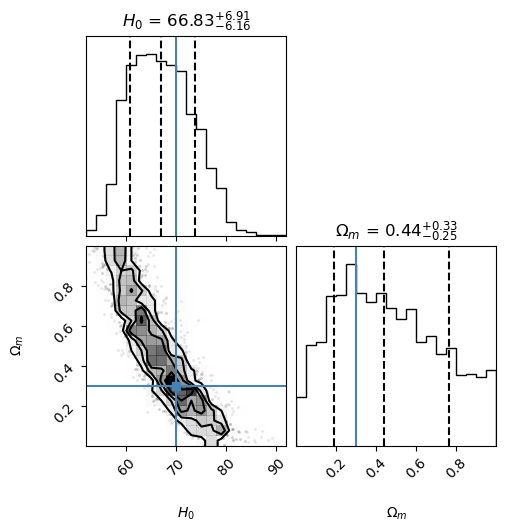

In [9]:
# estraiamo pesi e calcoliamo il campione pesato
weights = np.exp(results.logwt - results.logz[-1])
samples = dyutils.resample_equal(results.samples, weights)
# stima parametri e incertezze
h0_mcmc, om_mcmc = np.percentile(samples, [16, 50, 84], axis=0).T

print(f"H0     = {h0_mcmc[1]:.2f} + {h0_mcmc[2]-h0_mcmc[1]:.2f} / - {h0_mcmc[1]-h0_mcmc[0]:.2f} km/s/Mpc")
print(f"OmegaM = {om_mcmc[1]:.3f} + {om_mcmc[2]-om_mcmc[1]:.3f} / - {om_mcmc[1]-om_mcmc[0]:.3f}")
print(f"Log-Evidence (ln Z) = {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}")

labels = ["H0", "omegaM"]
fig = corner.corner(
    samples,
    labels=[r"$H_0$", r"$\Omega_m$"],
    truths=[70.0, 0.3], 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)

plt.show()

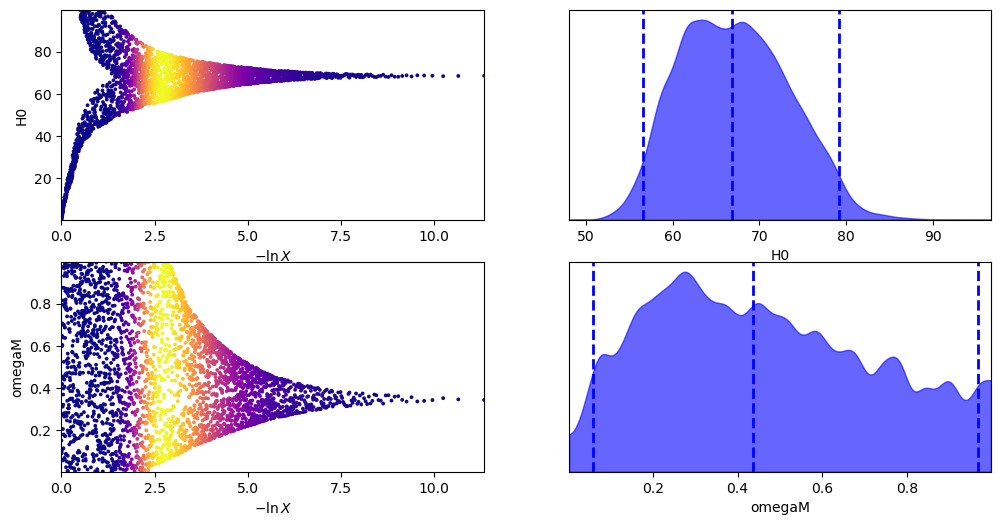

In [10]:
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.show()

Commenti: 
* I risultati del nested sampling si avvicinano molto a quelli noti, buono. il corner plot indica anti-correlazione tra Ho e Omega matter come previsto.
* Assenza di materia oscura significa Omega matter = 1. Il risultato indica che un valore estramamente improbabile, i dati sono a favore dell'esistenza di materia oscura.
* Si potrebbe fare nested sampling imponendo omega matter 1 e confrontare le evidence prodotte dai due modelli.
